## 1. Import libraries

In [2]:
# ── Standard Library ──────────────────────────────────────────────────────────
import warnings
import pickle
import os

# ── Data Manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn: Preprocessing ───────────────────────────────────────────────
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

# ── Scikit-learn: Models ──────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

# ── Scikit-learn: Metrics ─────────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── XGBoost ───────────────────────────────────────────────────────────────────
from xgboost import XGBRegressor

# ── Settings ──────────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 14, 'axes.labelsize': 12})
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42
CURRENT_YEAR = 2024   # Used for Car_Age computation

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## 2. Load Dataset & Initial Inspection

We load the CarDekho dataset and perform a basic structural inspection to understand its shape, data types, and statistical summary.

In [3]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
# Download URL (fallback if local file not present)
DATA_URL = "https://raw.githubusercontent.com/manishkr1754/CarDekho_Used_Car_Price_Prediction/main/notebooks/data/cardekho_dataset.csv"
DATA_PATH = "car_data.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"✅ Loaded local file: {DATA_PATH}")
else:
    df = pd.read_csv(DATA_URL)
    df.to_csv(DATA_PATH, index=False)          # cache locally
    print(f"✅ Downloaded and cached dataset to {DATA_PATH}")

✅ Loaded local file: car_data.csv


In [6]:
# ── First Five Rows ───────────────────────────────────────────────────────────
print("Shape:", df.shape)
df.head()

Shape: (4340, 8)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [7]:
# ── Data Types & Non-Null Counts ──────────────────────────────────────────────
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [8]:
# ── Statistical Summary ───────────────────────────────────────────────────────
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
year,4340.000000,2013.090783,4.215344,1992.000000,2011.000000,2014.000000,2016.000000,2020.000000
selling_price,4340.000000,504127.311751,578548.736139,20000.000000,208749.750000,350000.000000,600000.000000,8900000.000000
km_driven,4340.000000,66215.777419,46644.102194,1.000000,35000.000000,60000.000000,90000.000000,806599.000000


## 3. Data Cleaning

We check for and handle missing values and duplicate rows to ensure data quality before modelling.

In [9]:
# ── Missing Values ─────────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0] if missing_df['Missing Count'].sum() > 0
      else "✅ No missing values found.")

✅ No missing values found.


In [10]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [11]:
# ── Handle Missing Values (if any) ────────────────────────────────────────────
# Fill numeric columns with median; categorical with mode
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f"  Filled '{col}' (categorical) with mode: {df[col].mode()[0]}")
        else:
            df[col].fillna(df[col].median(), inplace=True)
            print(f"  Filled '{col}' (numeric) with median: {df[col].median():.2f}")

print(f"\n✅ Missing values after cleaning: {df.isnull().sum().sum()}")


✅ Missing values after cleaning: 0


In [12]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [13]:
# ── Duplicate Rows ─────────────────────────────────────────────────────────────
dup_count = df.duplicated().sum()
print(f"Duplicate rows found: {dup_count}")

if dup_count > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"✅ Duplicates removed. New shape: {df.shape}")
else:
    print("✅ No duplicate rows found.")

Duplicate rows found: 763
✅ Duplicates removed. New shape: (3577, 8)


In [14]:
df.head() 

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


## 4. Feature Engineering

We derive new meaningful features from existing columns:
- **Car_Age**: Number of years since the car was manufactured.
- **Brand**: Extracted from the first word of `Car_Name`.

In [15]:
# ── Car_Age: More intuitive than manufacturing year ────────────────────────────
df['Car_Age'] = CURRENT_YEAR - df['year']

# ── Drop original Year column (now redundant) ──────────────────────────────────
df.drop(columns=['year'], inplace=True)

# ── Brand: Extract manufacturer from Car_Name ──────────────────────────────────
df['Brand'] = df['name'].str.split().str[0].str.lower().str.strip()

# ── Drop Car_Name (high cardinality text — Brand captures the essential signal) ─
df.drop(columns=['name'], inplace=True)

print("✅ Feature engineering complete.")
print(f"Dataset shape: {df.shape}")
print(f"\nUnique brands ({df['Brand'].nunique()} total):")
print(sorted(df['Brand'].unique()))
df.head()

✅ Feature engineering complete.
Dataset shape: (3577, 8)

Unique brands (29 total):
['ambassador', 'audi', 'bmw', 'chevrolet', 'daewoo', 'datsun', 'fiat', 'force', 'ford', 'honda', 'hyundai', 'isuzu', 'jaguar', 'jeep', 'kia', 'land', 'mahindra', 'maruti', 'mercedes-benz', 'mg', 'mitsubishi', 'nissan', 'opelcorsa', 'renault', 'skoda', 'tata', 'toyota', 'volkswagen', 'volvo']


,selling_price,km_driven,fuel,seller_type,transmission,owner,Car_Age,Brand
0,60000,70000,Petrol,Individual,Manual,First Owner,17,maruti
1,135000,50000,Petrol,Individual,Manual,First Owner,17,maruti
2,600000,100000,Diesel,Individual,Manual,First Owner,12,hyundai
3,250000,46000,Petrol,Individual,Manual,First Owner,7,datsun
4,450000,141000,Diesel,Individual,Manual,Second Owner,10,honda


## 5. Exploratory Data Analysis (EDA)

We visualise the data to understand distributions, correlations, categorical relationships, popular brands, and outliers before modelling.

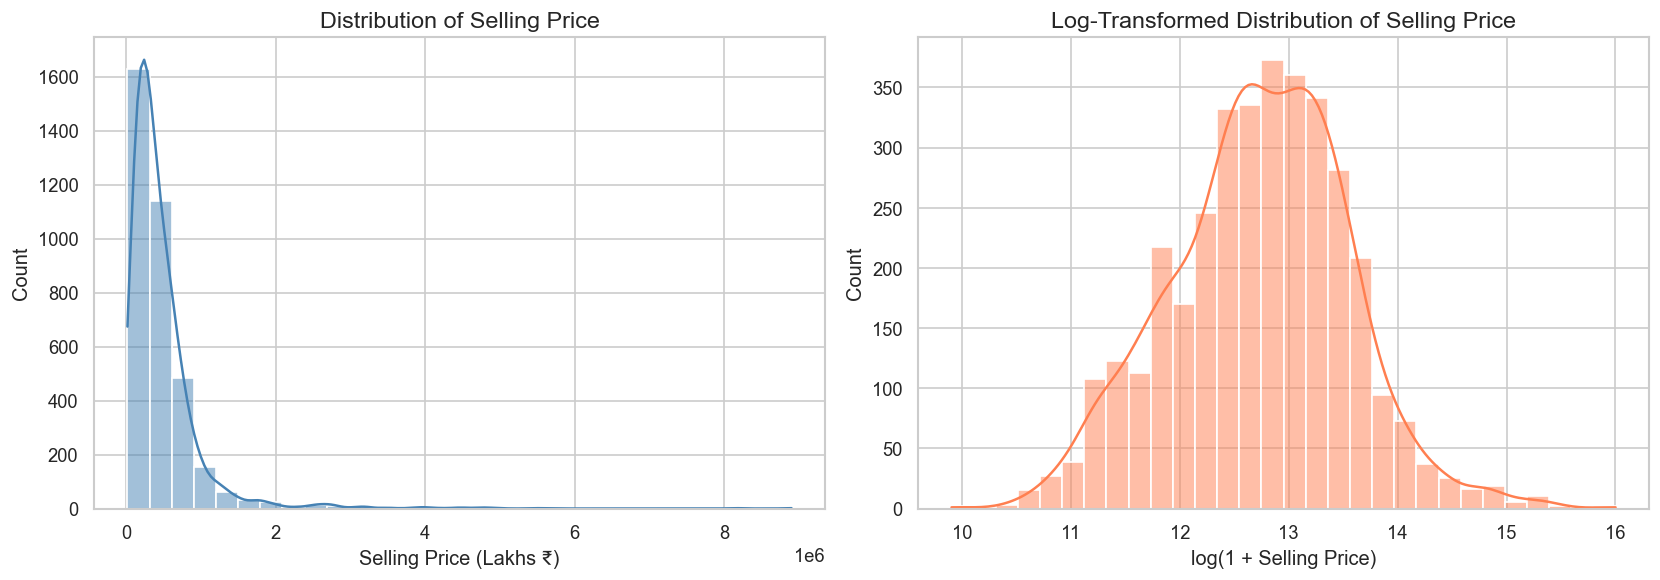

In [16]:
# ── 5.1 Distribution of Selling Price ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(df['selling_price'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Selling Price')
axes[0].set_xlabel('Selling Price (Lakhs ₹)')
axes[0].set_ylabel('Count')

# Log-transformed distribution (handles right-skew)
sns.histplot(np.log1p(df['selling_price']), bins=30, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Log-Transformed Distribution of Selling Price')
axes[1].set_xlabel('log(1 + Selling Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

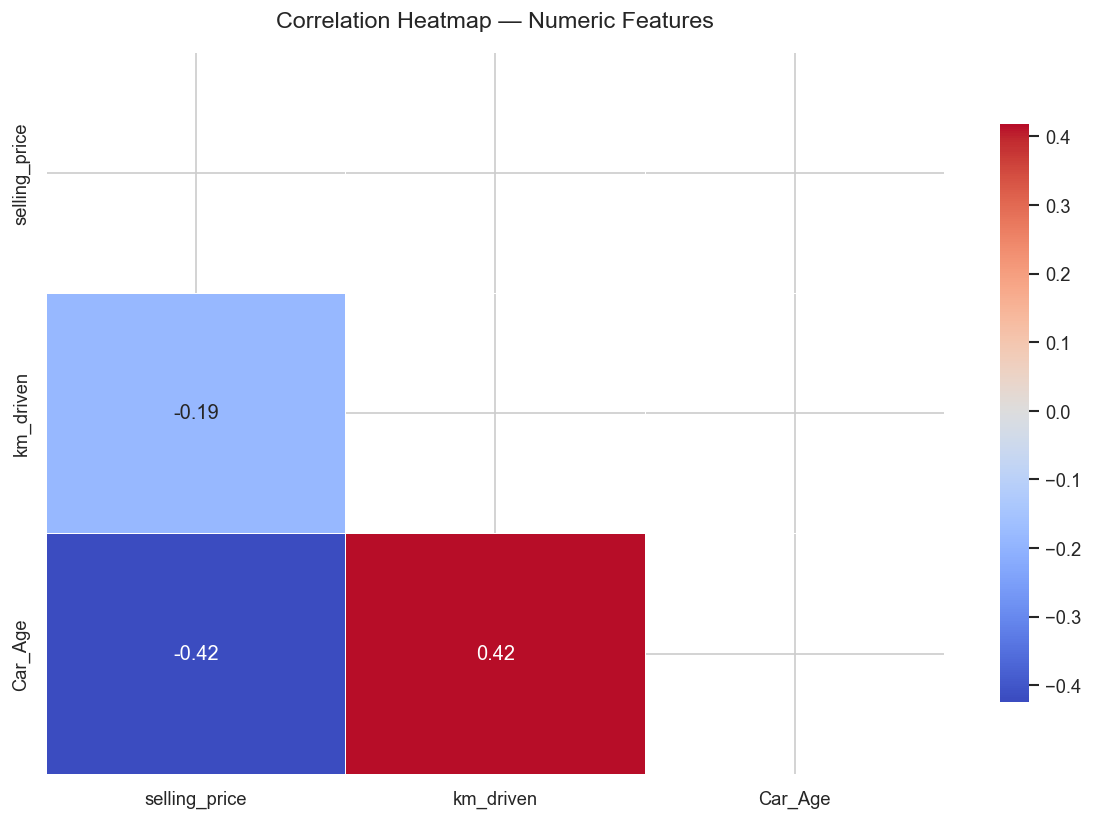


📌 Correlation with Selling_Price:
km_driven   -0.187359
Car_Age     -0.424260
Name: selling_price, dtype: float64


In [17]:
# ── 5.2 Correlation Heatmap ────────────────────────────────────────────────────
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 7))
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # mask upper triangle

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap — Numeric Features', pad=15)
plt.tight_layout()
#plt.savefig('plots/02_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("\n📌 Correlation with Selling_Price:")
print(corr_matrix['selling_price'].drop('selling_price').sort_values(ascending=False))

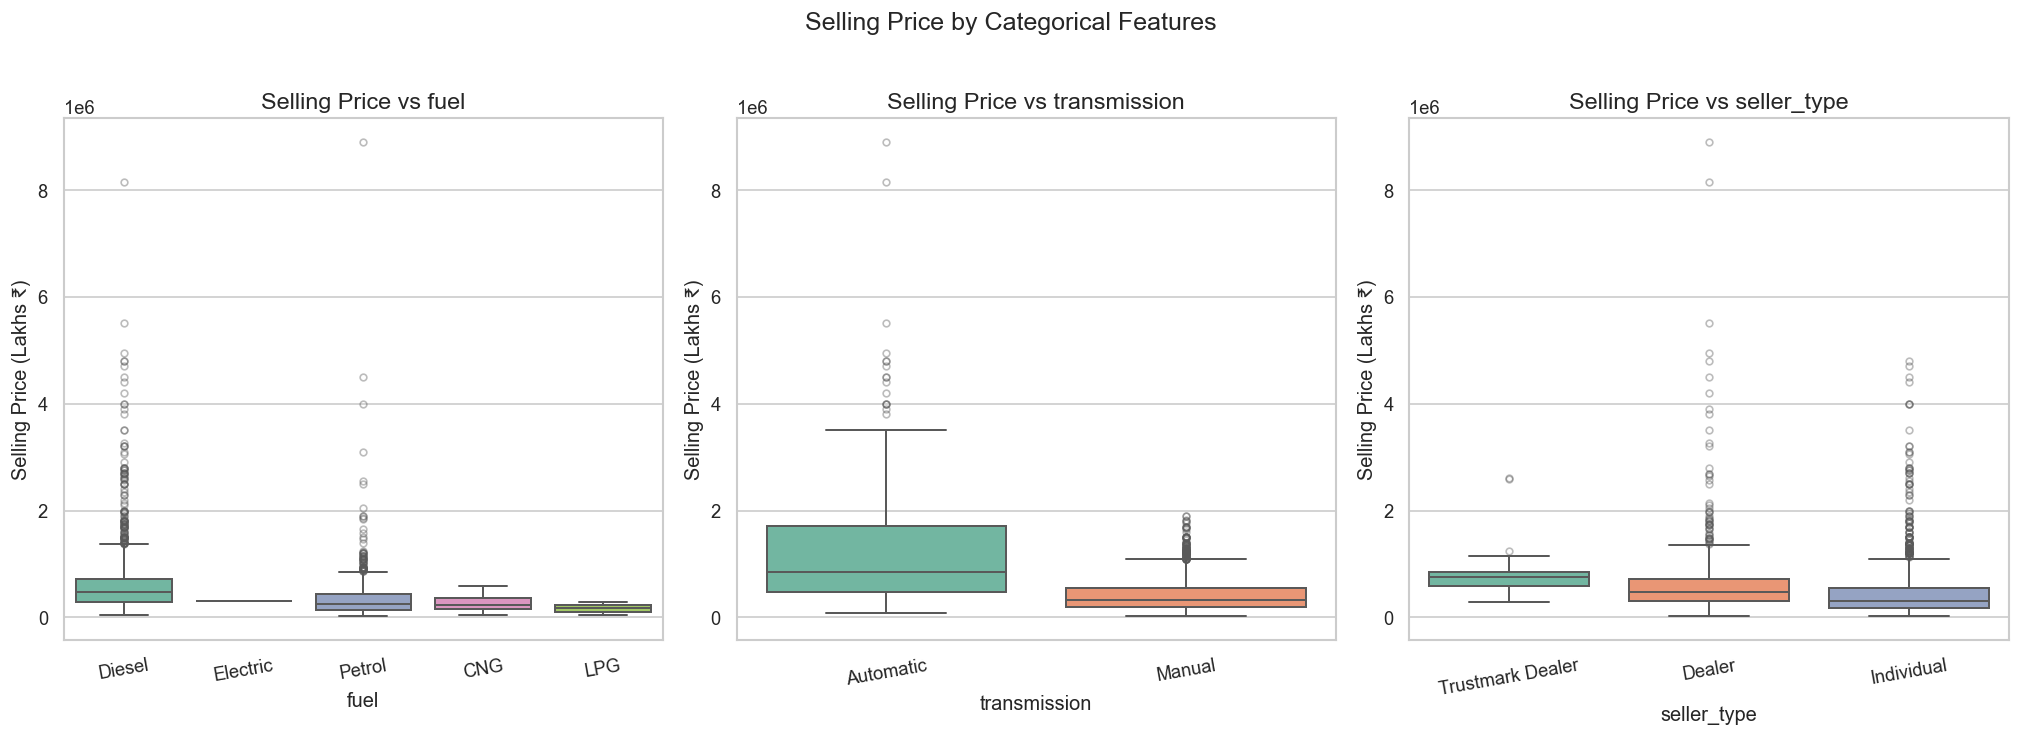

In [18]:
# ── 5.3 Selling Price vs Categorical Features ─────────────────────────────────
cat_cols = ['fuel', 'transmission', 'seller_type']
fig, axes = plt.subplots(1, 3, figsize=(17, 6))

palette = sns.color_palette('Set2')

for ax, col in zip(axes, cat_cols):
    order = df.groupby(col)['selling_price'].median().sort_values(ascending=False).index
    sns.boxplot(
        data=df, x=col, y='selling_price',
        order=order, palette=palette, ax=ax,
        linewidth=1.2, flierprops=dict(marker='o', markersize=4, alpha=0.4)
    )
    ax.set_title(f'Selling Price vs {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Selling Price (Lakhs ₹)')
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Selling Price by Categorical Features', fontsize=15, y=1.02)
plt.tight_layout()
#plt.savefig('plots/03_selling_price_vs_categoricals.png', bbox_inches='tight')
plt.show()

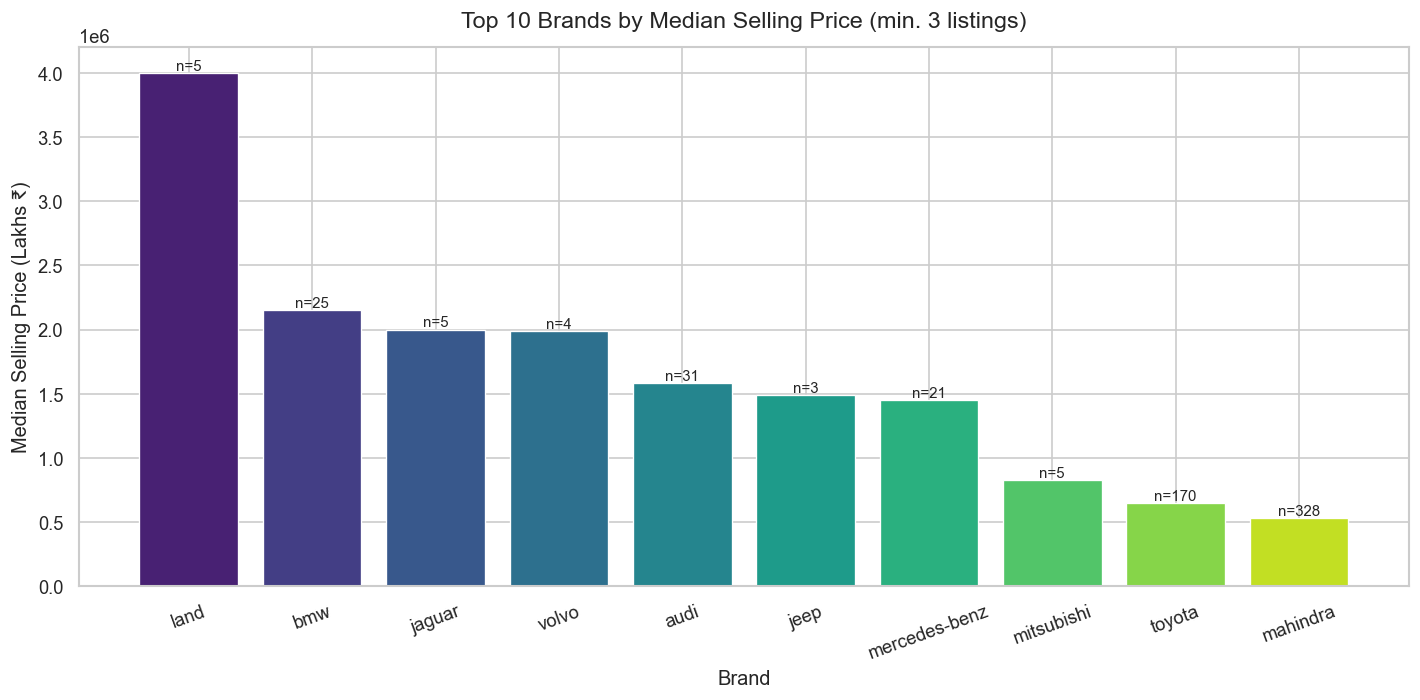

In [19]:
# ── 5.4 Top 10 Brands by Median Selling Price ─────────────────────────────────
top10_brands = (
    df.groupby('Brand')['selling_price']
      .agg(['median', 'count'])
      .query('count >= 3')            # at least 3 listings for reliability
      .sort_values('median', ascending=False)
      .head(10)
)

plt.figure(figsize=(12, 6))
bars = plt.bar(
    top10_brands.index,
    top10_brands['median'],
    color=sns.color_palette('viridis', len(top10_brands)),
    edgecolor='white', linewidth=0.8
)
# Annotate bars with count
for bar, (_, row) in zip(bars, top10_brands.iterrows()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f'n={int(row["count"])}',
        ha='center', va='bottom', fontsize=9
    )

plt.title('Top 10 Brands by Median Selling Price (min. 3 listings)', pad=12)
plt.xlabel('Brand')
plt.ylabel('Median Selling Price (Lakhs ₹)')
plt.xticks(rotation=20)
plt.tight_layout()
#plt.savefig('plots/04_top10_brands.png', bbox_inches='tight')
plt.show()

In [20]:
df.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,Car_Age,Brand
0,60000,70000,Petrol,Individual,Manual,First Owner,17,maruti
1,135000,50000,Petrol,Individual,Manual,First Owner,17,maruti
2,600000,100000,Diesel,Individual,Manual,First Owner,12,hyundai
3,250000,46000,Petrol,Individual,Manual,First Owner,7,datsun
4,450000,141000,Diesel,Individual,Manual,Second Owner,10,honda


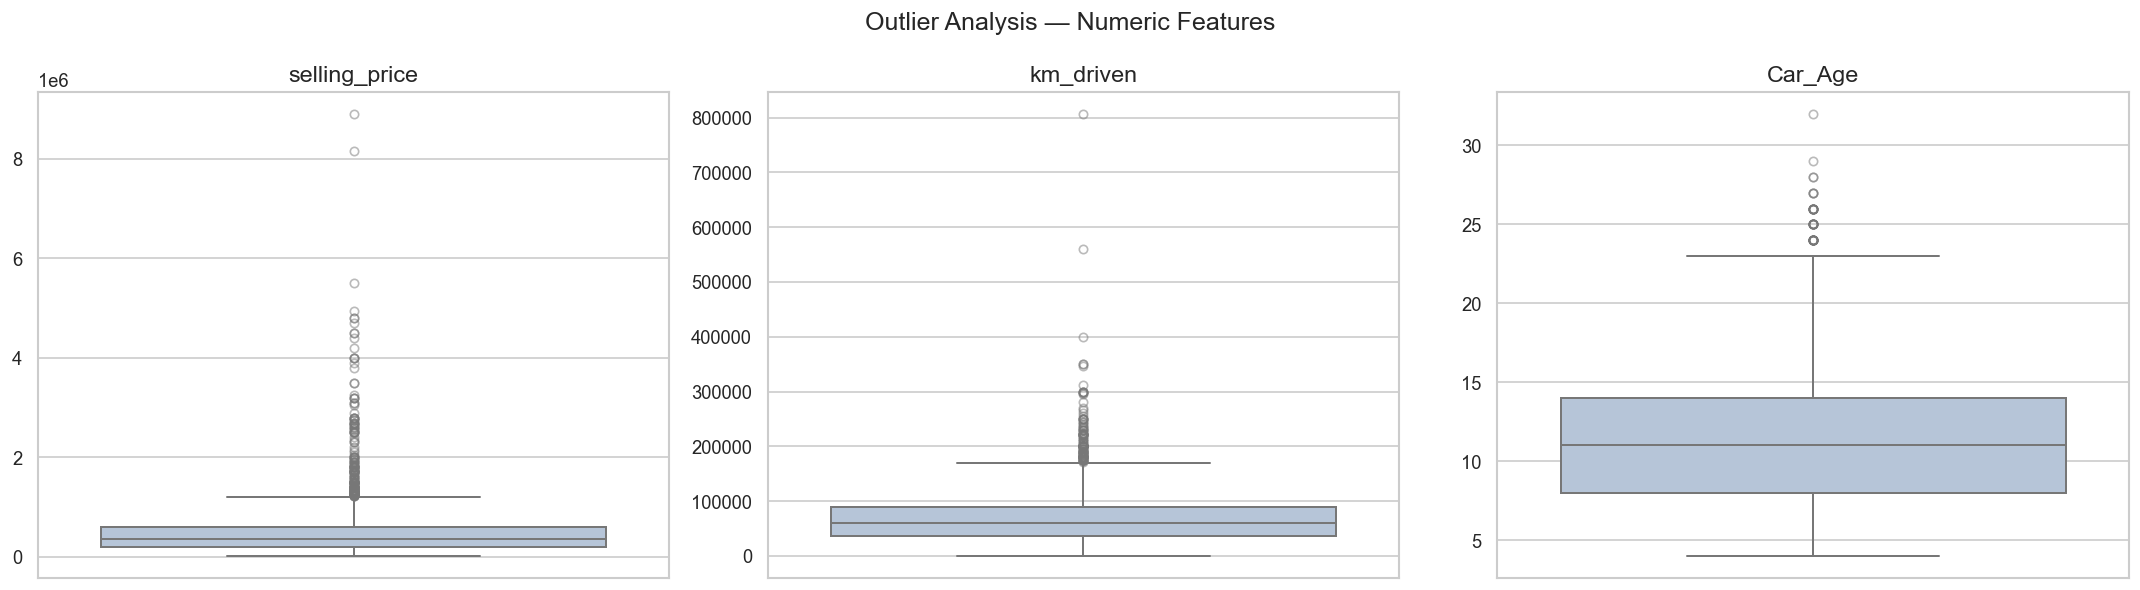


📌 Outlier counts per feature (IQR method):
  selling_price: 170 outliers
  km_driven: 106 outliers
  Car_Age: 37 outliers


In [21]:
# ── 5.5 Outlier Analysis — Boxplots for Numeric Features ──────────────────────
numeric_features = ['selling_price', 'km_driven', 'Car_Age']

fig, axes = plt.subplots(1, len(numeric_features), figsize=(18, 5))
for ax, col in zip(axes, numeric_features):
    sns.boxplot(
        y=df[col], ax=ax, color='lightsteelblue',
        linewidth=1.2,
        flierprops=dict(marker='o', color='red', alpha=0.5, markersize=5)
    )
    ax.set_title(col)
    ax.set_ylabel('')

plt.suptitle('Outlier Analysis — Numeric Features', fontsize=15)
plt.tight_layout()
#plt.savefig('plots/05_outlier_boxplots.png', bbox_inches='tight')
plt.show()

# ── IQR Outlier Summary ────────────────────────────────────────────────────────
print("\n📌 Outlier counts per feature (IQR method):")
for col in numeric_features:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col}: {n_out} outliers")

## 6. Encoding Categorical Variables

We use `pd.get_dummies()` with `drop_first=True` to convert categorical columns into numeric form (one-hot encoding), avoiding the **dummy variable trap**.

In [22]:
# ── Columns before encoding ────────────────────────────────────────────────────
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

# ── One-Hot Encoding with drop_first=True ─────────────────────────────────────
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"\nShape before encoding : {df.shape}")
print(f"Shape after  encoding : {df_encoded.shape}")
print(f"\nNew columns created:")
print([c for c in df_encoded.columns if c not in df.select_dtypes(exclude='object').columns])

Categorical columns to encode: ['fuel', 'seller_type', 'transmission', 'owner', 'Brand']

Shape before encoding : (3577, 8)
Shape after  encoding : (3577, 42)

New columns created:
['fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'owner_Fourth & Above Owner', 'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner', 'Brand_audi', 'Brand_bmw', 'Brand_chevrolet', 'Brand_daewoo', 'Brand_datsun', 'Brand_fiat', 'Brand_force', 'Brand_ford', 'Brand_honda', 'Brand_hyundai', 'Brand_isuzu', 'Brand_jaguar', 'Brand_jeep', 'Brand_kia', 'Brand_land', 'Brand_mahindra', 'Brand_maruti', 'Brand_mercedes-benz', 'Brand_mg', 'Brand_mitsubishi', 'Brand_nissan', 'Brand_opelcorsa', 'Brand_renault', 'Brand_skoda', 'Brand_tata', 'Brand_toyota', 'Brand_volkswagen', 'Brand_volvo']


## 7. Define Features and Target Variable

We separate the dataset into the feature matrix `X` and the target vector `y`.

In [23]:
# ── Target: Selling_Price ──────────────────────────────────────────────────────
y = df_encoded['selling_price']

# ── Features: all other columns ───────────────────────────────────────────────
X = df_encoded.drop(columns=['selling_price'])

print(f"Feature matrix X shape : {X.shape}")
print(f"Target vector  y shape : {y.shape}")
print(f"\nFeature columns ({X.shape[1]} total):")
print(X.columns.tolist())

Feature matrix X shape : (3577, 41)
Target vector  y shape : (3577,)

Feature columns (41 total):
['km_driven', 'Car_Age', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'owner_Fourth & Above Owner', 'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner', 'Brand_audi', 'Brand_bmw', 'Brand_chevrolet', 'Brand_daewoo', 'Brand_datsun', 'Brand_fiat', 'Brand_force', 'Brand_ford', 'Brand_honda', 'Brand_hyundai', 'Brand_isuzu', 'Brand_jaguar', 'Brand_jeep', 'Brand_kia', 'Brand_land', 'Brand_mahindra', 'Brand_maruti', 'Brand_mercedes-benz', 'Brand_mg', 'Brand_mitsubishi', 'Brand_nissan', 'Brand_opelcorsa', 'Brand_renault', 'Brand_skoda', 'Brand_tata', 'Brand_toyota', 'Brand_volkswagen', 'Brand_volvo']


## 8. Train-Test Split

We split the data into 80% training and 20% testing sets using a fixed `random_state` for reproducibility.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training set   : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set       : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

Training set   : 2861 samples (80.0%)
Test set       : 716 samples (20.0%)


## 9. Feature Scaling

- **Linear Regression** and **KNN** are sensitive to feature scale → we apply `StandardScaler`.
- **Random Forest** and **XGBoost** are tree-based and scale-invariant → we keep unscaled data.

In [25]:
# ── Initialise and fit scaler on training data ONLY ───────────────────────────
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform training
X_test_scaled  = scaler.transform(X_test)         # transform test (no leakage)

# ── Keep unscaled versions for tree-based models ──────────────────────────────
X_train_unscaled = X_train.copy()
X_test_unscaled  = X_test.copy()

print("✅ Feature scaling complete.")
print(f"Scaled   X_train shape : {X_train_scaled.shape}")
print(f"Unscaled X_train shape : {X_train_unscaled.shape}")

✅ Feature scaling complete.
Scaled   X_train shape : (2861, 41)
Unscaled X_train shape : (2861, 41)


## 10. Train Four Models

We train four different regression algorithms:
1. **Linear Regression** — simple baseline (scaled data)
2. **KNeighborsRegressor** — distance-based (scaled data)
3. **RandomForestRegressor** — ensemble of trees (unscaled data)
4. **XGBRegressor** — gradient boosting (unscaled data)

In [26]:
# ── 10.1 Linear Regression ────────────────────────────────────────────────────
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
print("✅ Linear Regression trained.")

# ── 10.2 K-Nearest Neighbors ──────────────────────────────────────────────────
knn_model = KNeighborsRegressor(n_neighbors=5, weights='uniform', metric='minkowski')
knn_model.fit(X_train_scaled, y_train)
print("✅ KNeighborsRegressor trained.")

# ── 10.3 Random Forest ────────────────────────────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=10,
    min_samples_split=5, random_state=RANDOM_STATE, n_jobs=-1
)
rf_model.fit(X_train_unscaled, y_train)
print("✅ RandomForestRegressor trained.")

# ── 10.4 XGBoost ──────────────────────────────────────────────────────────────
xgb_model = XGBRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=6, subsample=0.8,
    colsample_bytree=0.8, random_state=RANDOM_STATE,
    verbosity=0, n_jobs=-1
)
xgb_model.fit(X_train_unscaled, y_train)
print("✅ XGBRegressor trained.")

✅ Linear Regression trained.
✅ KNeighborsRegressor trained.
✅ RandomForestRegressor trained.
✅ XGBRegressor trained.


## 11. Make Predictions

We generate predictions on the held-out test set for all four models.

In [28]:
# ── Predictions ───────────────────────────────────────────────────────────────
y_pred_lr  = lr_model.predict(X_test_scaled)       # Linear Regression
y_pred_knn = knn_model.predict(X_test_scaled)      # KNN
y_pred_rf  = rf_model.predict(X_test_unscaled)     # Random Forest
y_pred_xgb = xgb_model.predict(X_test_unscaled)   # XGBoost

# Clip predictions to non-negative values (price can't be negative)
y_pred_lr  = np.clip(y_pred_lr,  0, None)
y_pred_knn = np.clip(y_pred_knn, 0, None)
y_pred_rf  = np.clip(y_pred_rf,  0, None)
y_pred_xgb = np.clip(y_pred_xgb, 0, None)

print("✅ Predictions generated for all four models.")

✅ Predictions generated for all four models.


## 12. Model Evaluation

We define a reusable evaluation function that returns **MAE**, **RMSE**, and **R² Score**, then compare all models.

In [29]:
def evaluate_model(name: str, y_true, y_pred) -> dict:
    """
    Compute regression metrics for a single model.

    Parameters
    ----------
    name   : str   – model display name
    y_true : array – ground-truth target values
    y_pred : array – model predictions

    Returns
    -------
    dict with MAE, RMSE, and R² Score
    """
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {'Model': name, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4), 'R² Score': round(r2, 4)}


# ── Evaluate all models ───────────────────────────────────────────────────────
results = pd.DataFrame([
    evaluate_model('Linear Regression',    y_test, y_pred_lr),
    evaluate_model('KNN',                  y_test, y_pred_knn),
    evaluate_model('Random Forest',        y_test, y_pred_rf),
    evaluate_model('XGBoost',              y_test, y_pred_xgb),
]).sort_values('R² Score', ascending=False).reset_index(drop=True)

print("📊 Model Comparison (sorted by R² Score):")
results.style.background_gradient(subset=['R² Score'], cmap='RdYlGn') \
             .background_gradient(subset=['MAE', 'RMSE'], cmap='RdYlGn_r')

📊 Model Comparison (sorted by R² Score):


,Model,MAE,RMSE,R² Score
0,Random Forest,152736.015400,350037.235800,0.619600
1,XGBoost,144940.078100,354716.245700,0.609400
2,Linear Regression,175104.004700,383608.143700,0.543200
3,KNN,167453.600800,409551.893600,0.479300


In [30]:
# ── Identify best model ───────────────────────────────────────────────────────
best_model_name = results.iloc[0]['Model']
print(f"🏆 Best model: {best_model_name}")
print(results.iloc[0])

🏆 Best model: Random Forest
Model       Random Forest
MAE           152736.0154
RMSE          350037.2358
R² Score           0.6196
Name: 0, dtype: object


## 13. Actual vs Predicted — Best Model Visualisation

A scatter plot where points on the diagonal red line represent perfect predictions.

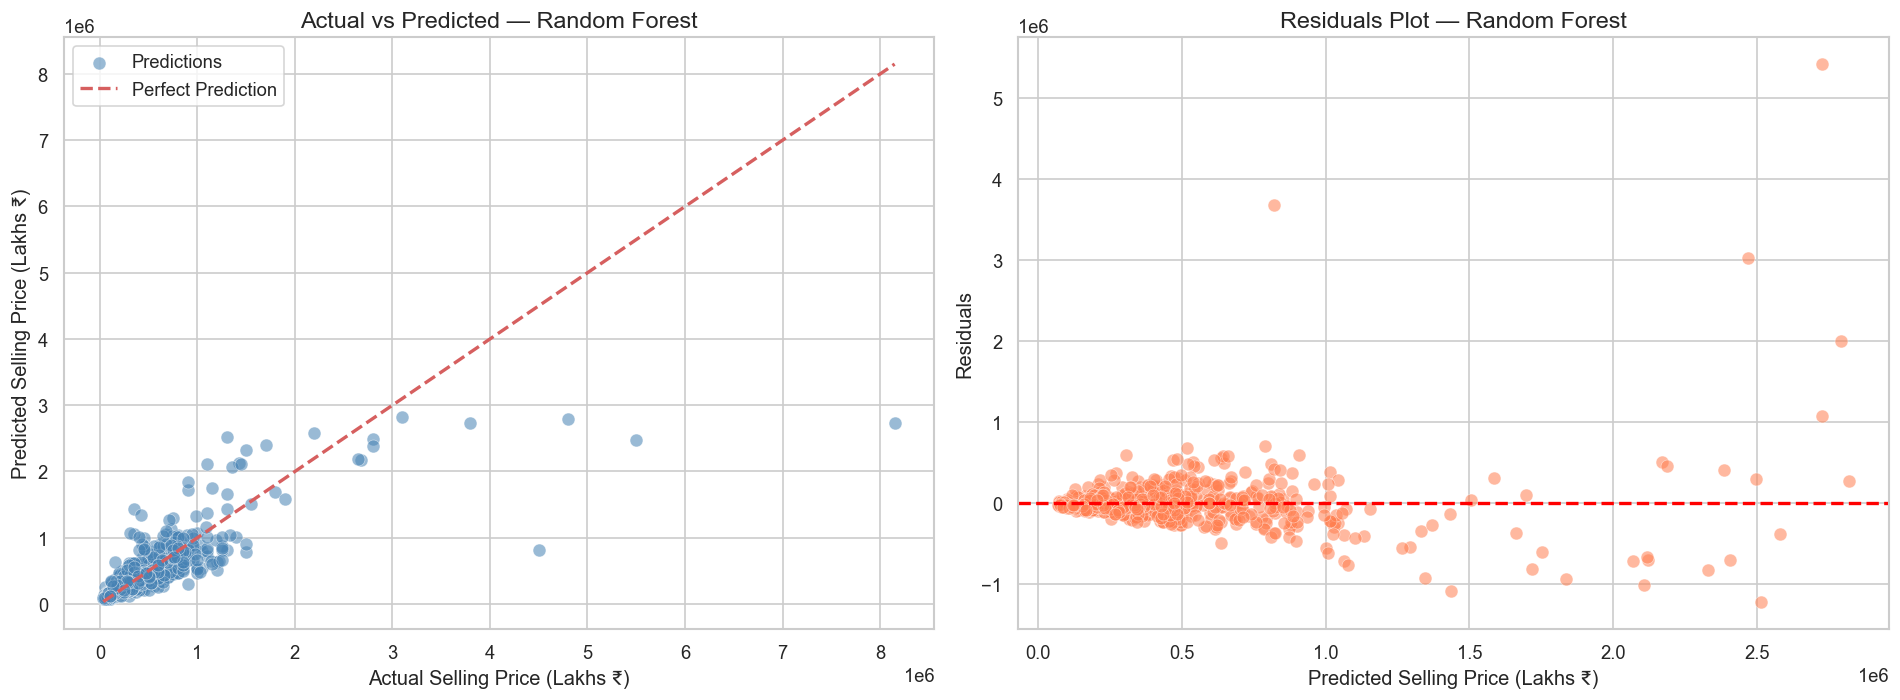

In [31]:
# ── Select predictions for the best model ────────────────────────────────────
pred_map = {
    'Linear Regression': y_pred_lr,
    'KNN':               y_pred_knn,
    'Random Forest':     y_pred_rf,
    'XGBoost':           y_pred_xgb,
}
best_preds = pred_map[best_model_name]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Scatter: Actual vs Predicted ---
ax = axes[0]
ax.scatter(y_test, best_preds, alpha=0.55, edgecolors='white', linewidths=0.4,
           color='steelblue', s=60, label='Predictions')
lims = [min(y_test.min(), best_preds.min()),
        max(y_test.max(), best_preds.max())]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Selling Price (Lakhs ₹)')
ax.set_ylabel('Predicted Selling Price (Lakhs ₹)')
ax.set_title(f'Actual vs Predicted — {best_model_name}')
ax.legend()

# --- Residuals Plot ---
ax2 = axes[1]
residuals = y_test.values - best_preds
ax2.scatter(best_preds, residuals, alpha=0.55, edgecolors='white',
            linewidths=0.4, color='coral', s=60)
ax2.axhline(0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Predicted Selling Price (Lakhs ₹)')
ax2.set_ylabel('Residuals')
ax2.set_title(f'Residuals Plot — {best_model_name}')

plt.tight_layout()
#plt.savefig('plots/06_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

## 14. Hyperparameter Tuning with RandomizedSearchCV

We tune the best model using `RandomizedSearchCV` with 5-fold cross-validation to find optimal hyperparameters without exhaustive grid search.

In [32]:
# ── Define parameter grid based on best model ─────────────────────────────────
if best_model_name in ['Random Forest', 'XGBoost']:
    if best_model_name == 'Random Forest':
        base_estimator = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
        param_dist = {
            'n_estimators'     : [100, 200, 300, 500],
            'max_depth'        : [None, 5, 10, 15, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf' : [1, 2, 4],
            'max_features'     : ['sqrt', 'log2', None],
        }
        tune_X_train, tune_X_test = X_train_unscaled, X_test_unscaled

    else:  # XGBoost
        base_estimator = XGBRegressor(random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
        param_dist = {
            'n_estimators'   : [100, 200, 300, 500],
            'learning_rate'  : [0.01, 0.05, 0.1, 0.2],
            'max_depth'      : [3, 5, 6, 8, 10],
            'subsample'      : [0.6, 0.7, 0.8, 0.9, 1.0],
            'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
        }
        tune_X_train, tune_X_test = X_train_unscaled, X_test_unscaled

else:  # Linear Regression / KNN
    base_estimator = KNeighborsRegressor()
    param_dist = {
        'n_neighbors': list(range(3, 21)),
        'weights'    : ['uniform', 'distance'],
        'metric'     : ['minkowski', 'euclidean', 'manhattan'],
    }
    tune_X_train, tune_X_test = X_train_scaled, X_test_scaled

print(f"🔍 Tuning: {best_model_name}")
print(f"   Parameter search space: {param_dist}")

🔍 Tuning: Random Forest
   Parameter search space: {'n_estimators': [100, 200, 300, 500], 'max_depth': [None, 5, 10, 15, 20], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'max_features': ['sqrt', 'log2', None]}


In [33]:
# ── RandomizedSearchCV: 30 iterations, 5-fold CV ─────────────────────────────
random_search = RandomizedSearchCV(
    estimator=base_estimator,
    param_distributions=param_dist,
    n_iter=30,                        # number of random parameter combinations
    cv=5,                             # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

random_search.fit(tune_X_train, y_train)

print(f"\n✅ Best CV R² Score : {random_search.best_score_:.4f}")
print(f"   Best parameters  : {random_search.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best CV R² Score : 0.6891
   Best parameters  : {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


## 15. Retrain & Evaluate the Tuned Model

📊 Before vs After Tuning:
                Model         MAE        RMSE  R² Score
        Random Forest 152736.0154 350037.2358    0.6196
Random Forest (Tuned) 149134.9773 364986.7653    0.5865


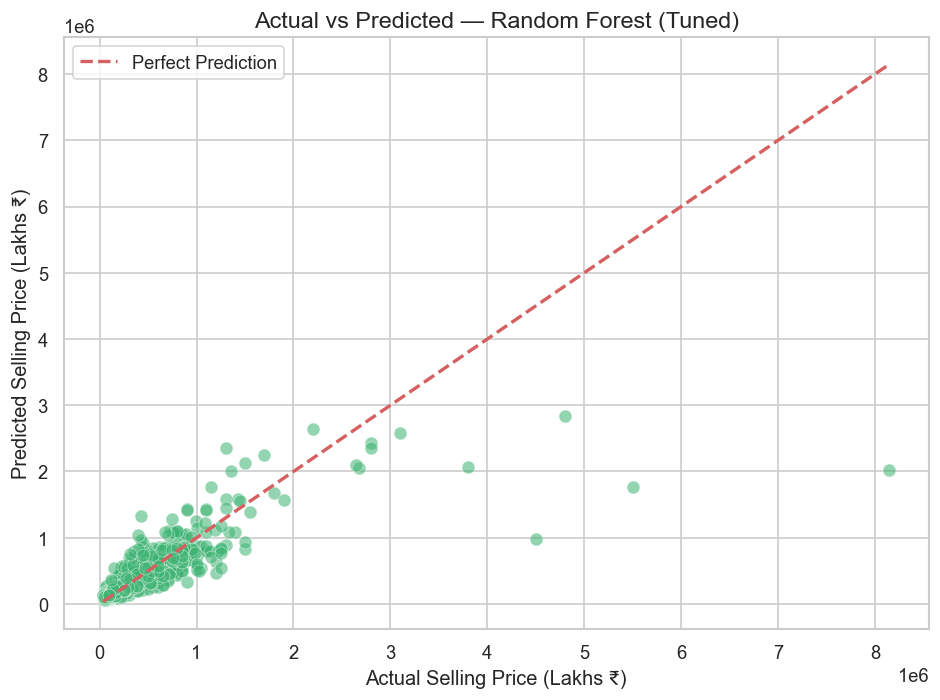

In [ ]:
# ── Use the best estimator found by RandomizedSearchCV ───────────────────────
tuned_model = random_search.best_estimator_

# ── Predictions with tuned model ──────────────────────────────────────────────
y_pred_tuned = np.clip(tuned_model.predict(tune_X_test), 0, None)

# ── Evaluate ──────────────────────────────────────────────────────────────────
tuned_metrics = evaluate_model(f'{best_model_name} (Tuned)', y_test, y_pred_tuned)

print("📊 Before vs After Tuning:")
before = results[results['Model'] == best_model_name].iloc[0].to_dict()
comparison = pd.DataFrame([before, tuned_metrics])
print(comparison.to_string(index=False))

# ── Visual Comparison: Actual vs Predicted (Tuned) ────────────────────────────
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_tuned, alpha=0.55, edgecolors='white',
            linewidths=0.4, color='mediumseagreen', s=60)
lims = [min(y_test.min(), y_pred_tuned.min()),
        max(y_test.max(), y_pred_tuned.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Selling Price (Lakhs ₹)')
plt.ylabel('Predicted Selling Price (Lakhs ₹)')
plt.title(f'Actual vs Predicted — {best_model_name} (Tuned)')
plt.legend()
plt.tight_layout()
#plt.savefig('plots/07_tuned_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

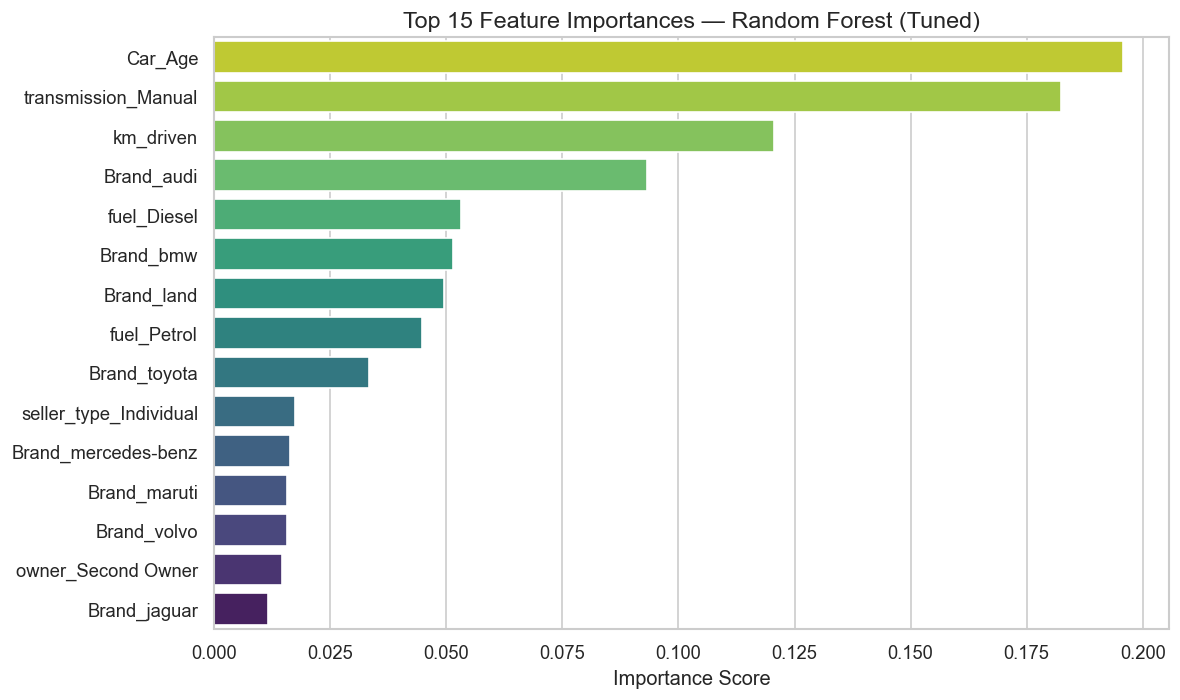

In [ ]:
# ── Feature Importance (tree-based models only) ───────────────────────────────
if hasattr(tuned_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature'   : X.columns,
        'Importance': tuned_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df, x='Importance', y='Feature',
                palette='viridis_r', orient='h')
    plt.title(f'Top 15 Feature Importances — {best_model_name} (Tuned)')
    plt.xlabel('Importance Score')
    plt.ylabel('')
    plt.tight_layout()
    #plt.savefig('plots/08_feature_importance.png', bbox_inches='tight')
    plt.show()
else:
    print("Feature importance not available for this model type.")

## 16. Save the Final Model with Pickle

We persist both the trained model and the scaler so they can be loaded for inference without retraining.

In [ ]:
# ── Create output directory ───────────────────────────────────────────────────
os.makedirs('models', exist_ok=True)

MODEL_PATH  = 'models/model.pkl'
SCALER_PATH = 'models/scaler.pkl'

# ── Save the tuned model ──────────────────────────────────────────────────────
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(tuned_model, f)

# ── Save the scaler ───────────────────────────────────────────────────────────
with open(SCALER_PATH, 'wb') as f:
    pickle.dump(scaler, f)

print(f"✅ Model  saved → {MODEL_PATH}")
print(f"✅ Scaler saved → {SCALER_PATH}")

# ── Verify: Reload and predict ────────────────────────────────────────────────
with open(MODEL_PATH, 'rb') as f:
    loaded_model = pickle.load(f)

reload_pred = np.clip(loaded_model.predict(tune_X_test[:5]), 0, None)
print(f"\n🔄 Verification — first 5 predictions from reloaded model:")
print(f"   Predicted : {reload_pred.round(2)}")
print(f"   Actual    : {y_test.values[:5].round(2)}")

✅ Model  saved → models/model.pkl
✅ Scaler saved → models/scaler.pkl

🔄 Verification — first 5 predictions from reloaded model:
   Predicted : [ 567085.94  460312.77 1246999.56 2060907.55  245265.15]
   Actual    : [ 270000  525000  990000 3800000  229999]


## 17. Final Results Summary

In [ ]:
# ── Final consolidated comparison ─────────────────────────────────────────────
final_results = pd.concat(
    [results,
     pd.DataFrame([tuned_metrics])],
    ignore_index=True
).sort_values('R² Score', ascending=False).reset_index(drop=True)

print("=" * 60)
print("         FINAL MODEL COMPARISON SUMMARY")
print("=" * 60)
print(final_results.to_string(index=False))
print("=" * 60)

best_row = final_results.iloc[0]
print(f"\n🏆 Best Model  : {best_row['Model']}")
print(f"   MAE         : {best_row['MAE']:.4f} Lakhs ₹")
print(f"   RMSE        : {best_row['RMSE']:.4f} Lakhs ₹")
print(f"   R² Score    : {best_row['R² Score']:.4f}  ({best_row['R² Score']*100:.2f}% variance explained)")

         FINAL MODEL COMPARISON SUMMARY
                Model         MAE        RMSE  R² Score
        Random Forest 152736.0154 350037.2358    0.6196
              XGBoost 144940.0781 354716.2457    0.6094
Random Forest (Tuned) 149134.9773 364986.7653    0.5865
    Linear Regression 175104.0047 383608.1437    0.5432
                  KNN 167453.6008 409551.8936    0.4793

🏆 Best Model  : Random Forest
   MAE         : 152736.0154 Lakhs ₹
   RMSE        : 350037.2358 Lakhs ₹
   R² Score    : 0.6196  (61.96% variance explained)


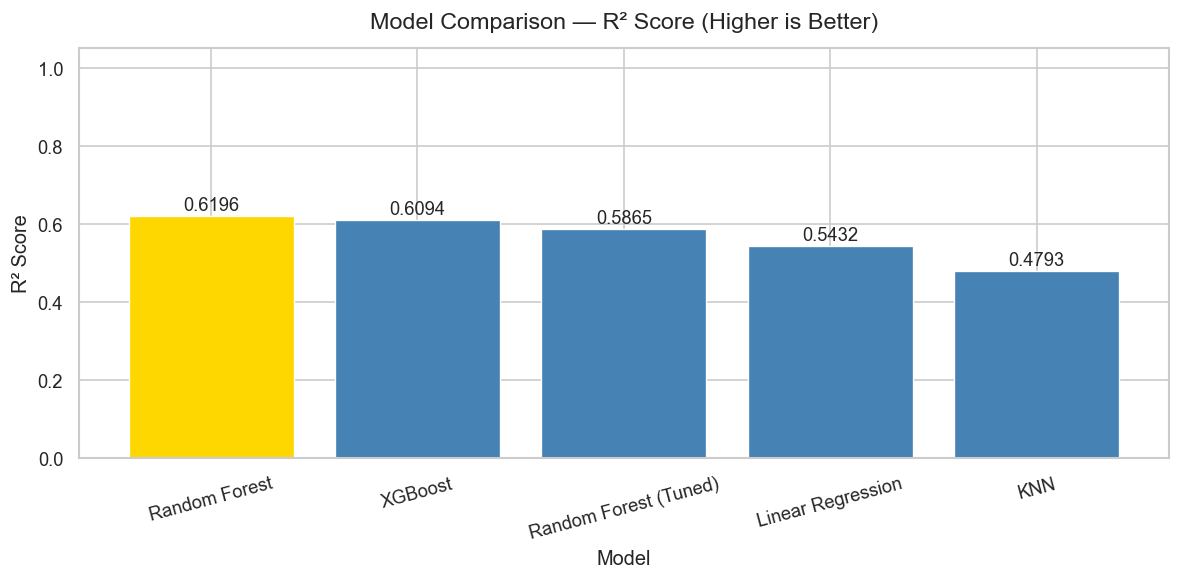

In [ ]:
# ── Bar chart: R² Score comparison ────────────────────────────────────────────
plt.figure(figsize=(10, 5))
colors = ['gold' if r == final_results['R² Score'].max() else 'steelblue'
          for r in final_results['R² Score']]

bars = plt.bar(final_results['Model'], final_results['R² Score'],
               color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, final_results['R² Score']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11)

plt.ylim(0, 1.05)
plt.title('Model Comparison — R² Score (Higher is Better)', pad=12)
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.xticks(rotation=15)
plt.tight_layout()
#plt.savefig('plots/09_model_comparison_r2.png', bbox_inches='tight')
plt.show()